<a href="https://colab.research.google.com/github/sidersaurio/labs/blob/main/Logistic_Differential_Equation_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Build a PINN from scratch

### The Neural Network

**PINN (originally pinn.py):** The following utility module includes some common routines needed to setup a PINN.

In [12]:
from collections import OrderedDict
from dataclasses import dataclass
from typing import Callable

import torch
from torch import nn
from torch.func import functional_call, grad, vmap


@dataclass
class Config:
    num_hidden: int = 5
    dim_hidden: int = 5
    batch_size: int = 32
    learning_rate: float = 1e-1
    num_epochs: int = 100


class LinearNN(nn.Module):
    def __init__(
        self,
        num_inputs: int = 1,
        num_layers: int = 1,
        num_neurons: int = 5,
        act: nn.Module = nn.Tanh(),
    ) -> None:
        """Basic neural network architecture with linear layers

        Args:
            num_inputs (int, optional): the dimensionality of the input tensor
            num_layers (int, optional): the number of hidden layers
            num_neurons (int, optional): the number of neurons for each hidden layer
            act (nn.Module, optional): the non-linear activation function to use for stitching
                linear layers togeter
        """
        super().__init__()

        self.num_inputs = num_inputs
        self.num_neurons = num_neurons
        self.num_layers = num_layers

        layers = []

        # input layer
        layers.append(nn.Linear(self.num_inputs, num_neurons))

        # hidden layers with linear layer and activation
        for _ in range(num_layers):
            layers.extend([nn.Linear(num_neurons, num_neurons), act])

        # output layer
        layers.append(nn.Linear(num_neurons, 1))

        # build the network
        self.network = nn.Sequential(*layers)

    def forward(self, *inputs: tuple[torch.Tensor, ...]) -> torch.Tensor:

        if len(inputs) != self.num_inputs:
            raise ValueError(f"Expected {self.num_inputs} inputs, got {len(inputs)}")

        if self.num_inputs == 1:
            input = inputs[0]
            return self.network(input.reshape(-1, 1)).squeeze()
        else:

            # NOTE
            # when receiving vectors from the application of a grad
            # higher-order function, the type of the tensor is slightly
            # different and their shape is not defined. With these tensors,
            # stacking works on dimension 0, thus the definition
            # of the `dim` variable below
            dim = int(all([input.shape for input in inputs]))

            input = torch.stack(inputs, dim=dim)
            return self.network(input).squeeze()


def make_forward_fn_1d(
    model: nn.Module,
    derivative_order: int = 1,
) -> list[Callable]:
    """Make a functional forward pass and gradient functions given an input model in 1-dimension

    This function creates a set of functional calls of the input model

    It returns a list of composable v-mapped version of the forward pass
    and of higher-order derivatives with respect to the inputs as
    specified by the input argument `derivative_order`

    Args:
        model (nn.Module): the model to make the functional calls for. It can be any subclass of
            a nn.Module
        derivative_order (int, optional): Up to which order return functions for computing the
            derivative of the model with respect to the inputs

    Returns:
        list[Callable]: A list of functions where each element corresponds to
            a v-mapped version of the model forward pass and its derivatives. The
            0-th element is always the forward pass and, depending on the value of
            the `derivative_order` argument, the following elements corresponds to
            the i-th order derivative function with respect to the model inputs. The
            vmap ensures efficient support for batched inputs
    """
    # notice that `functional_call` supports batched input by default
    # thus there is not need to call vmap on it, as it's instead the case
    # for the derivative calls
    def f(x: torch.Tensor, params: dict[str, torch.nn.Parameter] | tuple[torch.nn.Parameter, ...]) -> torch.Tensor:

        # the functional optimizer works with parameters represented as a tuple instead
        # of the dictionary form required by the `functional_call` API
        # here we perform the conversion from tuple to dictionary
        if isinstance(params, tuple):
            params_dict = tuple_to_dict_parameters(model, params)
        else:
            params_dict = params

        return functional_call(model, params_dict, (x, ))

    fns = []
    fns.append(f)

    dfunc = f
    for _ in range(derivative_order):

        # first compute the derivative function
        dfunc = grad(dfunc)

        # then use vmap to support batching
        dfunc_vmap = vmap(dfunc, in_dims=(0, None))

        fns.append(dfunc_vmap)

    return fns


def make_forward_fn_nd(
    model: nn.Module,
    on_variable: int,
    derivative_order: int = 1,
) -> list[Callable]:
    """Make a functional forward pass and gradient functions given an input model in n-dimensions.

    The parameters are exactly as the function above. The call to `grad` has been replaced with
    a call to the reversed mode AD `jacrev` which computes the Jacobian of the function. Notice that
    `jacrev` automatically supports batched inputs.
    """

    # notice that `functional_call` supports batched input by default
    def f(*inputs: torch.Tensor, params: dict[str, torch.nn.Parameter] | tuple[torch.nn.Parameter, ...] = None) -> torch.Tensor:
        if isinstance(params, tuple):
            params_dict = tuple_to_dict_parameters(model, params)
        else:
            params_dict = params

        return functional_call(model, params_dict, inputs)

    fns = []
    fns.append(f)

    dfunc = f
    for _ in range(derivative_order):

        dfunc = grad(dfunc, argnums=on_variable)
        dfunc_vmap = vmap(dfunc)

        fns.append(dfunc_vmap)

    return fns


def tuple_to_dict_parameters(
        model: nn.Module, params: tuple[torch.nn.Parameter, ...]
) -> OrderedDict[str, torch.nn.Parameter]:
    """Convert a set of parameters stored as a tuple into a dictionary form

    This conversion is required to be able to call the `functional_call` API which requires
    parameters in a dictionary form from the results of a functional optimization step which
    returns the parameters as a tuple

    Args:
        model (nn.Module): the model to make the functional calls for. It can be any subclass of
            a nn.Module
        params (tuple[Parameter, ...]): the model parameters stored as a tuple

    Returns:
        An OrderedDict instance with the parameters stored as an ordered dictionary
    """
    keys = list(dict(model.named_parameters()).keys())
    values = list(params)
    return OrderedDict(({k:v for k,v in zip(keys, values)}))

**Plotting (originally plotting.py)**

In [13]:

from typing import Callable

import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.animation import FuncAnimation
import torch
from torch import Tensor


def plot_1d_solution(
    x_eval: Tensor,
    x_sample: Tensor,
    f_eval: Tensor,
    analytical_sol_fn: Callable,
    loss_evolution: Tensor,
    show: bool = True,
) -> Figure:
    """
    Plot the solution of a 1-dimension differential equation

    Args:
        x_eval (torch.Tensor): Evaluation points for the solution.
        f_eval (torch.Tensor): Evaluated solution at the evaluation points.
        analytical_sol_fn (callable): Analytical solution function.
        x_sample_np (numpy.ndarray): Sample training points.
        loss_evolution (list): List of loss values at each epoch.
    """
    x_eval_np = x_eval.detach().numpy()
    x_sample_np = x_sample.detach().numpy()

    fig, ax = plt.subplots()

    ax.scatter(x_sample_np, analytical_sol_fn(x_sample_np), color="red", label="Sample training points")
    ax.plot(x_eval_np, f_eval.detach().numpy(), label="PINN final solution")
    ax.plot(
        x_eval_np,
        analytical_sol_fn(x_eval_np),
        label="Analytic solution",
        color="green",
        alpha=0.75,
    )
    ax.set(title="Equation solved with NNs", xlabel="t", ylabel="f(t)")
    ax.legend()

    fig, ax = plt.subplots()
    ax.semilogy(loss_evolution)
    ax.set(title="Loss evolution", xlabel="# epochs", ylabel="Loss")
    ax.legend()

    if show:
        plt.show()

    return fig


def animate_2d_solution(
    x_eval: Tensor,
    t_eval: Tensor,
    opt_params: tuple,
    fn: Callable,
    show: bool = True
) -> tuple[Figure, FuncAnimation]:
    """
    Animate the solution of a 2-dimension problem in time and space

    Args:
        x_eval (Tensor): Evaluation points for the spatial dimension.
        t_eval (Tensor): Evaluation points for the time dimension.
        opt_params (tuple): Optimal parameters computed after the training procedure.
        fn (Callable): The function to animate.
        show (bool, optional): Whether to display the animation. Defaults to True.

    Returns:
        tuple[Figure, FuncAnimation]: A tuple containing the matplotlib Figure and FuncAnimation objects.
    """
    fig, ax = plt.subplots()
    line, = ax.plot([], [], lw=2)

    ax.set(title="Equation solved with NNs", xlabel="x", ylabel="u(x,t)")

    def init() -> tuple:
        ax.set_xlim(x_eval[0].item(), x_eval[-1].item())
        y_values = [fn(x_eval, t * torch.ones_like(x_eval), params=opt_params).detach().numpy() for t in t_eval]
        ax.set_ylim(min(map(min, y_values)), max(map(max, y_values)))
        return line,

    def animate(frame: int) -> tuple:
        t = t_eval[frame]
        y = fn(x_eval, t * torch.ones_like(x_eval), params=opt_params)
        line.set_data(x_eval.detach().numpy(), y.detach().numpy())
        return line,

    ani = FuncAnimation(
        fig, animate, frames=len(t_eval), init_func=init, blit=True, interval=200, repeat=False
    )

    if show:
        plt.show()

    return fig, ani

**Training (originally training.py)**

In [14]:
!pip install torchopt

In [15]:
from typing import Callable

import torch
import torchopt
from torch import Tensor


def train_pinn(
    model: torch.nn.Module,
    loss_fn: Callable,
    domain_sampler: Callable,
    learning_rate: float = 1e-3,
    num_iter: int = 100,
) -> tuple[tuple[Tensor, ...], Tensor]:

    print_every = num_iter // min(num_iter, 50)

    # choose optimizer with functional API using functorch
    optimizer = torchopt.FuncOptimizer(torchopt.adam(lr=learning_rate))

    # initial parameters, randomly initialized
    params = tuple(model.parameters())

    # train the model
    loss_evolution = []
    for i in range(num_iter):

        # sample points in the domain for each epoch
        x = domain_sampler()

        # compute the loss with the current parameters
        loss = loss_fn(params, x)

        # update the parameters with functional optimizer
        params = optimizer.step(loss, params)

        if i % print_every == 0:
            print(f"Iteration {i} with loss {loss.detach().item()}") # Modified this line

        loss_evolution.append(float(loss))

    return params, loss_evolution


### Imports

In [16]:
from typing import Callable
import argparse

import torch
from torch import nn
import numpy as np

'''
IMPORTANT: The next imports originally called python modules, but for this notebook were executed on the previous code cells!!!
from pinn import make_forward_fn_1d, LinearNN
from plotting import plot_1d_solution
from training import train_pinn
'''

'\nIMPORTANT: The next imports originally called python modules, but for this notebook were executed on the previous code cells!!!\nfrom pinn import make_forward_fn_1d, LinearNN\nfrom plotting import plot_1d_solution\nfrom training import train_pinn\n'

### Boundary conditions

In [17]:
R = 1.0  # rate of maximum population growth parameterizing the equation
X_BOUNDARY = 0.0  # boundary condition coordinate
F_BOUNDARY = 0.5  # boundary condition value

### Crafting the loss function

/tmp/ipykernel_2425/2192521157.py:38: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f"Iteration {i} with loss {float(loss)}")


Iteration 0 with loss 0.6875214576721191
Iteration 2 with loss 0.0613323450088501
Iteration 4 with loss 0.060336850583553314
Iteration 6 with loss 0.06132698059082031
Iteration 8 with loss 0.056064020842313766
Iteration 10 with loss 0.034501511603593826
Iteration 12 with loss 0.01398435514420271
Iteration 14 with loss 0.018317606300115585
Iteration 16 with loss 0.022073861211538315
Iteration 18 with loss 0.020954838022589684
Iteration 20 with loss 0.013831223361194134
Iteration 22 with loss 0.013024188578128815
Iteration 24 with loss 0.0032003475353121758
Iteration 26 with loss 0.014230795204639435
Iteration 28 with loss 0.009232047945261002
Iteration 30 with loss 0.0031866386998444796
Iteration 32 with loss 0.004407278727740049
Iteration 34 with loss 0.008410363458096981
Iteration 36 with loss 0.0057198842987418175
Iteration 38 with loss 0.0022838586010038853
Iteration 40 with loss 0.0027761550154536963
Iteration 42 with loss 0.002609358634799719
Iteration 44 with loss 0.0013478600885

/tmp/ipykernel_2425/294764539.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


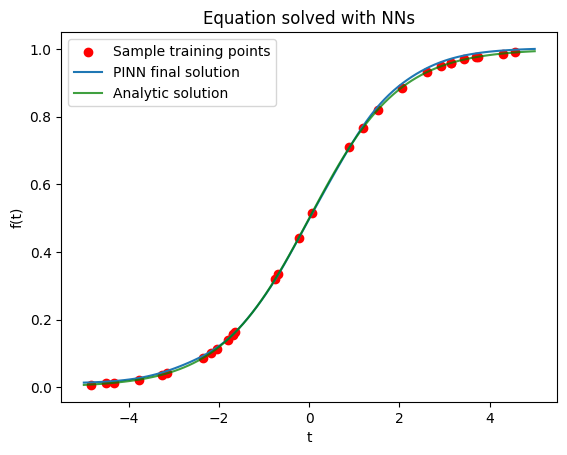

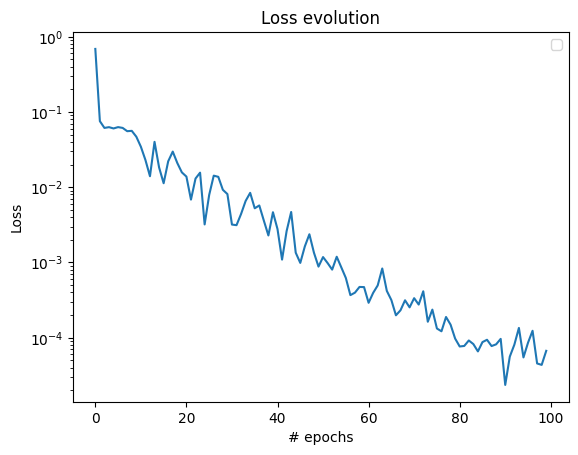

In [19]:
from typing import Callable
import argparse

import torch
from torch import nn
import numpy as np

'''
Modules directly executed on previous cells
from pinn import make_forward_fn_1d, LinearNN
from plotting import plot_1d_solution
from training import train_pinn
'''

R = 1.0  # rate of maximum population growth parameterizing the equation
X_BOUNDARY = 0.0  # boundary condition coordinate
F_BOUNDARY = 0.5  # boundary condition value


def make_loss_fn(f: Callable, dfdx: Callable) -> Callable:
    """Make a function loss evaluation function

    The loss is computed as sum of the interior MSE loss (the differential equation residual)
    and the MSE of the loss at the boundary

    Args:
        f (Callable): The functional forward pass of the model used a universal function approximator. This
            is a function with signature (x, params) where `x` is the input data and `params` the model
            parameters
        dfdx (Callable): The functional gradient calculation of the universal function approximator. This
            is a function with signature (x, params) where `x` is the input data and `params` the model
            parameters

    Returns:
        Callable: The loss function with signature (params, x) where `x` is the input data and `params` the model
            parameters. Notice that a simple call to `dloss = functorch.grad(loss_fn)` would give the gradient
            of the loss with respect to the model parameters needed by the optimizers
    """

    def loss_fn(params: torch.Tensor, x: torch.Tensor):

        # interior loss
        f_value = f(x, params)
        interior = dfdx(x, params) - R * f_value * (1 - f_value)

        # boundary loss
        x0 = X_BOUNDARY
        f0 = F_BOUNDARY
        x_boundary = torch.tensor([x0])
        f_boundary = torch.tensor([f0])
        boundary = f(x_boundary, params) - f_boundary

        loss = nn.MSELoss()
        loss_value = loss(interior, torch.zeros_like(interior)) + loss(
            boundary, torch.zeros_like(boundary)
        )

        return loss_value

    return loss_fn


if __name__ == "__main__":

    # make it reproducible
    torch.manual_seed(42)

    # parse input from user
    parser = argparse.ArgumentParser()

    parser.add_argument("-n", "--num-hidden", type=int, default=5)
    parser.add_argument("-d", "--dim-hidden", type=int, default=5)
    parser.add_argument("-b", "--batch-size", type=int, default=30)
    parser.add_argument("-lr", "--learning-rate", type=float, default=1e-1)
    parser.add_argument("-e", "--num-epochs", type=int, default=100)

    args = parser.parse_args([])

    # configuration
    num_hidden: int = args.num_hidden
    dim_hidden: int = args.dim_hidden
    batch_size: int = args.batch_size
    num_iter: int = args.num_epochs
    tolerance = 1e-8
    learning_rate: float = args.learning_rate

    domain = (-5.0, 5.0)

    # function versions of model forward, gradient and loss
    model = LinearNN(num_layers=num_hidden, num_neurons=dim_hidden, num_inputs=1)
    funcs = make_forward_fn_1d(model, derivative_order=1)

    f = funcs[0]
    dfdx = funcs[1]
    loss_fn = make_loss_fn(f, dfdx)

    def domain_sampler() -> torch.Tensor:
        return torch.FloatTensor(batch_size).uniform_(domain[0], domain[1])

    opt_params, loss_evolution = train_pinn(
        model,
        loss_fn,
        domain_sampler,
        learning_rate=learning_rate,
        num_iter=num_iter,
    )

    x_eval = torch.linspace(domain[0], domain[1], steps=100).reshape(-1, 1)
    x_sample = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1])
    f_eval = f(x_eval, tuple(opt_params))

    def analytical_sol_fn(x):
        return 1.0 / (1.0 + (1.0 / F_BOUNDARY - 1.0) * np.exp(-R * x))

    plot_1d_solution(x_eval, x_sample, f_eval, analytical_sol_fn, loss_evolution, show=True)


The error is due to argparse trying to process arguments automatically passed by the Colab environment. I've updated the code to explicitly tell argparse to ignore these arguments.

The training process completed successfully, and the plots illustrate the PINN's solution and loss evolution. To address the UserWarning about converting a tensor with requires_grad=True to a scalar, I'll update the print statement to detach the loss tensor first. This ensures cleaner logging without affecting the training mechanics.